# Bloque 2. Formatos básicos: CSV y Excel

**Módulo ETCDFM (5104) · UD2: Formatos de fichero de datos**

---

CSV y Excel son los formatos de intercambio de datos más extendidos en entornos empresariales y científicos. A pesar de su sencillez aparente, presentan numerosas variantes y problemas que hay que conocer para trabajar con ellos de forma robusta.


## Contenidos

1. CSV en profundidad: estructura, delimitadores, quoting y escape
2. Codificaciones y variantes (TSV, pipe-separated)
3. Problemas habituales en CSV
4. Lectura de CSV con pandas: `read_csv`
5. Escritura de CSV con pandas: `to_csv`
6. Formato Excel (.xlsx): estructura interna
7. Lectura de Excel con pandas: `read_excel`
8. Escritura de Excel: `to_excel` y `ExcelWriter`
9. Comparativa CSV vs Excel


## 2.1 Estructura de un fichero CSV

Un fichero **CSV** (*Comma-Separated Values*) es texto plano en el que cada línea es un registro y los campos están separados por un carácter delimitador.

```
id,nombre,precio,"descripcion larga"
1,"García, Ana",28.50,"Camisa de algodón 100%"
2,Luis,31.00,Pantalon vaquero
3,,45.75,"Precio sin nombre"
```

Elementos clave:
- **Delimitador**: carácter que separa campos (`','` por defecto, también `';'` o `'\t'`)
- **Quoting**: comillas dobles `""` encierran campos que contienen el delimitador o saltos de línea
- **Escape**: dentro de comillas, `""` representa una comilla literal
- **Cabecera**: primera fila con nombres de columnas (convención, no obligatorio)
- **Valores vacíos**: campo vacío entre delimitadores → `NaN` en pandas


In [1]:
import pandas as pd

# Los tres ficheros contienen el mismo dataset de 600 productos
# con diferentes separadores y formato decimal

print('--- CSV estandar (sep=",", 600 filas) ---')
df_coma = pd.read_csv('datos/productos.csv')
print(df_coma[['id','nombre','precio','categoria']].head(4).to_string(index=False))

print('\n--- CSV europeo (sep=";", decimal=",") ---')
df_sc = pd.read_csv('datos/productos_sc.csv', sep=';', decimal=',')
print(df_sc[['id','nombre','precio','categoria']].head(4).to_string(index=False))

print('\n--- TSV (sep="\\t") ---')
df_tab = pd.read_csv('datos/productos_tab.tsv', sep='\t')
print(df_tab[['id','nombre','precio','categoria']].head(4).to_string(index=False))

print(f'\nLos tres DataFrames son identicos: {df_coma.equals(df_sc) and df_coma.equals(df_tab)}')
print(f'Shape comun: {df_coma.shape}')


--- CSV estandar (sep=",", 600 filas) ---
 id        nombre  precio categoria
  1  Smart S 0000  383.53  Libreria
  2 Max 3000 0001  261.97  Libreria
  3    Max L 0002  554.99     Hogar
  4 Smart 4K 0003  821.01   Deporte

--- CSV europeo (sep=";", decimal=",") ---
 id        nombre  precio categoria
  1  Smart S 0000  383.53  Libreria
  2 Max 3000 0001  261.97  Libreria
  3    Max L 0002  554.99     Hogar
  4 Smart 4K 0003  821.01   Deporte

--- TSV (sep="\t") ---
 id        nombre  precio categoria
  1  Smart S 0000  383.53  Libreria
  2 Max 3000 0001  261.97  Libreria
  3    Max L 0002  554.99     Hogar
  4 Smart 4K 0003  821.01   Deporte

Los tres DataFrames son identicos: True
Shape comun: (600, 9)


## 2.2 Codificaciones y variantes

**Codificaciones habituales:**
- **UTF-8** — estándar actual; soporta cualquier carácter Unicode. Usar siempre por defecto.
- **Latin-1 (ISO-8859-1)** — común en ficheros exportados desde sistemas Windows antiguos o software europeo.
- **UTF-8 con BOM** — UTF-8 con marca de byte al inicio; problemático si pandas no lo espera. Usar `encoding='utf-8-sig'` para manejarlo.

**Variantes de CSV:**
- **TSV** (*Tab-Separated Values*, `.tsv`) — separador tabulador. Útil cuando los datos contienen comas.
- **Pipe-separated** (`.csv` o `.txt`) — separador `|`. Frecuente en exports de ERP/bases de datos.
- **Punto y coma** — estándar en países europeos donde la coma es separador decimal.

> **Regla práctica**: antes de leer un CSV desconocido, abre los primeros bytes con un editor de texto para identificar separador y codificación.


In [2]:
import pandas as pd

# ventas_latin1.csv: 200 filas con nombres de ciudades con tildes,
# guardado en Latin-1 con sep=';' y decimal=','

# Intento 1: encoding incorrecto
print('Intentando leer con encoding="utf-8" (incorrecto):')
try:
    df_err = pd.read_csv('datos/ventas_latin1.csv', sep=';', encoding='utf-8')
    # Puede no dar error si los chars son ASCII-compatibles, pero los muestra mal
    print(df_err.head(3).to_string(index=False))
    print('(sin excepcion, pero pueden aparecer caracteres incorrectos)')
except UnicodeDecodeError as e:
    print(f'  Error UnicodeDecodeError: {e}')

# Intento 2: encoding correcto
print('\nLectura correcta con encoding="latin-1" y decimal=",":')
df_ok = pd.read_csv('datos/ventas_latin1.csv', sep=';', decimal=',', encoding='latin-1')
print(df_ok.head(6).to_string(index=False))
print(f'\nShape: {df_ok.shape}')
print(f'dtype importe: {df_ok["importe"].dtype}  (float64 porque decimal="," convierte correctamente)')


Intentando leer con encoding="utf-8" (incorrecto):
  Error UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf3 in position 1: invalid continuation byte

Lectura correcta con encoding="latin-1" y decimal=",":
 id  ciudad  importe      fecha
  1 Córdoba  1337.71 01/01/2023
  2  Málaga   497.23 02/01/2023
  3  Gerona  1435.94 03/01/2023
  4  Málaga  1199.88 04/01/2023
  5 Córdoba   431.48 05/01/2023
  6 Almería  1703.71 06/01/2023

Shape: (200, 4)
dtype importe: float64  (float64 porque decimal="," convierte correctamente)


## 2.3 Problemas habituales en CSV

| Problema | Causa | Solucion en pandas |
|---|---|---|
| Tipos erróneos | `precio` leído como string | `dtype={'precio': float}` |
| Fechas como string | Sin parsing automático | `parse_dates=['fecha']` |
| Valores nulos no estándar | `'N/A'`, `'-'`, `'null'` | `na_values=['N/A', '-', 'null']` |
| Salto de línea en campo | Sin quoting correcto | `quoting=csv.QUOTE_ALL` al escribir |
| Cabeceras duplicadas | Export defectuoso | `mangle_dupe_cols=True` (pandas < 2) |
| Columnas extra al final | Separador sobrante | `index_col=False` |
| Encoding incorrecto | Latin-1 vs UTF-8 | `encoding='latin-1'` |

La detección temprana de estos problemas evita errores silenciosos difíciles de depurar.


In [3]:
import pandas as pd, io

# 1. Campo con salto de linea (requiere quoting)
csv1 = 'id,descripcion,precio\n1,"Camisa\nazul",28.50\n2,Pantalon,45.00'
df1 = pd.read_csv(io.StringIO(csv1))
print('1. Campo con salto de linea (quoting):')
print(f'   descripcion[0] = {repr(df1["descripcion"][0])}')

# 2. Tipos implicitos: fecha leida como string
df_prod = pd.read_csv('datos/productos.csv')
print(f'\n2. Tipo inferido de fecha_alta sin parse_dates: {df_prod["fecha_alta"].dtype}')
df_prod2 = pd.read_csv('datos/productos.csv', parse_dates=['fecha_alta'])
print(f'   Tipo con parse_dates=["fecha_alta"]:           {df_prod2["fecha_alta"].dtype}')

# 3. Valores nulos reales: descuento_pct tiene NaN (25% de filas)
print(f'\n3. Nulos en productos.csv:')
nulos = df_prod.isnull().sum()
print(nulos[nulos > 0].to_string())

# 4. Nulos en ventas: descuento_aplicado
df_ventas = pd.read_csv('datos/ventas_2023.csv')
nulos_v = df_ventas.isnull().sum()
print(f'\n4. Nulos en ventas_2023.csv:')
print(nulos_v[nulos_v > 0].to_string())
print(f'   ({nulos_v["descuento_aplicado"]}/{len(df_ventas)} filas sin descuento aplicado)')


1. Campo con salto de linea (quoting):
   descripcion[0] = 'Camisa\nazul'

2. Tipo inferido de fecha_alta sin parse_dates: object
   Tipo con parse_dates=["fecha_alta"]:           datetime64[ns]

3. Nulos en productos.csv:
descuento_pct    434

4. Nulos en ventas_2023.csv:
descuento_aplicado    972
   (972/1200 filas sin descuento aplicado)


## 2.4 Lectura de CSV con `read_csv` — parámetros básicos

```python
pd.read_csv(filepath_or_buffer, sep=',', header='infer',
            names=None, skiprows=None, nrows=None,
            encoding='utf-8', na_values=None, index_col=None)
```

| Parámetro | Descripcion | Ejemplo |
|---|---|---|
| `sep` | Separador de campos | `sep=';'` |
| `header` | Fila con cabecera (`0`=primera, `None`=sin cabecera) | `header=None` |
| `names` | Lista de nombres de columnas | `names=['id','nombre']` |
| `skiprows` | Filas a saltar al inicio | `skiprows=3` |
| `nrows` | Máximo de filas a leer | `nrows=1000` |
| `encoding` | Codificación del fichero | `encoding='latin-1'` |
| `na_values` | Valores extra a tratar como NaN | `na_values=['-','N/A']` |
| `index_col` | Columna a usar como índice | `index_col='id'` |


In [4]:
import pandas as pd

# Leer el fichero de productos (600 filas, 9 columnas)
df = pd.read_csv('datos/productos.csv')

print(f'Shape: {df.shape}')
print(f'Memoria (sin optimizar): {df.memory_usage(deep=True).sum():,} bytes\n')
print('Tipos inferidos automaticamente:')
print(df.dtypes)
print()
df.head(5)


Shape: (600, 9)
Memoria (sin optimizar): 162,363 bytes

Tipos inferidos automaticamente:
id                 int64
nombre            object
categoria         object
precio           float64
stock              int64
fecha_alta        object
proveedor         object
activo              bool
descuento_pct    float64
dtype: object



,id,nombre,categoria,precio,stock,fecha_alta,proveedor,activo,descuento_pct
0,1,Smart S 0000,Libreria,383.53,163,2020-01-01,FoodImport SA,True,NaN
1,2,Max 3000 0001,Libreria,261.97,300,2020-01-01,HomeMart SL,True,NaN
2,3,Max L 0002,Hogar,554.99,406,2020-01-02,SportZone SL,True,34.9
3,4,Smart 4K 0003,Deporte,821.01,302,2020-01-03,HomeMart SL,True,NaN
4,5,Basic 2000 0004,Hogar,128.64,286,2020-01-03,ModaPlus SA,True,NaN


## `read_csv` — parámetros avanzados

| Parámetro | Descripcion | Ejemplo |
|---|---|---|
| `dtype` | Forzar tipos de columnas | `dtype={'precio':'float32'}` |
| `parse_dates` | Parsear columnas como fechas | `parse_dates=['fecha_alta']` |
| `usecols` | Leer solo algunas columnas | `usecols=['id','precio']` |
| `chunksize` | Leer en bloques (iterador) | `chunksize=10_000` |
| `compression` | Leer comprimido directamente | `compression='gzip'` |
| `thousands` | Separador de miles en números | `thousands='.'` |
| `decimal` | Separador decimal | `decimal=','` |

> **Consejo de rendimiento**: `usecols` reduce la memoria proporcionalmente al número de columnas omitidas. Combinado con `dtype`, puede reducir el uso de RAM un 50–80 %.


In [5]:
import pandas as pd

# usecols: leer solo las columnas necesarias
cols = ['id_pedido', 'fecha', 'total', 'ciudad', 'metodo_pago']
df_cols = pd.read_csv('datos/ventas_2023.csv', usecols=cols)
print(f'usecols {cols}:')
print(f'  shape={df_cols.shape}  memoria={df_cols.memory_usage(deep=True).sum():,} bytes\n')

# dtype: reducir memoria con tipos especificos
df_full = pd.read_csv('datos/ventas_2023.csv')
df_opt  = pd.read_csv('datos/ventas_2023.csv',
                      dtype={'total': 'float32', 'cantidad': 'int16',
                             'categoria': 'category', 'metodo_pago': 'category',
                             'region': 'category'})
mem_full = df_full.memory_usage(deep=True).sum()
mem_opt  = df_opt.memory_usage(deep=True).sum()
print(f'dtype optimizado: {mem_full:,} -> {mem_opt:,} bytes  (ahorro {100*(1-mem_opt/mem_full):.0f}%)\n')

# parse_dates
df_d = pd.read_csv('datos/ventas_2023.csv', parse_dates=['fecha'])
print(f'parse_dates -> fecha: {df_d["fecha"].dtype}\n')

# chunksize: acumular estadisticas por trozos
totales_ciudad = {}
for chunk in pd.read_csv('datos/ventas_2023.csv', chunksize=200):
    for ciudad, grupo in chunk.groupby('ciudad')['total'].sum().items():
        totales_ciudad[ciudad] = totales_ciudad.get(ciudad, 0) + grupo
top5 = sorted(totales_ciudad.items(), key=lambda x: -x[1])[:5]
print('chunksize=200 — Top 5 ciudades por ventas:')
for c, t in top5:
    print(f'  {c:<20} {t:>12,.2f} EUR')


usecols ['id_pedido', 'fecha', 'total', 'ciudad', 'metodo_pago']:
  shape=(1200, 5)  memoria=232,624 bytes

dtype optimizado: 485,156 -> 269,619 bytes  (ahorro 44%)

parse_dates -> fecha: datetime64[ns]

chunksize=200 — Top 5 ciudades por ventas:
  Murcia                 331,054.62 EUR
  Alicante               319,431.99 EUR
  Barcelona              314,558.82 EUR
  Malaga                 300,767.22 EUR
  Madrid                 298,578.98 EUR


## Fuente pública: catálogo sísmico USGS

El **USGS** (United States Geological Survey) publica un catálogo sísmico mundial en formato CSV directamente descargable desde su API.

```
URL: https://earthquake.usgs.gov/fdsnws/event/1/query
     ?format=csv&starttime=2024-01-01&endtime=2024-03-31
     &minmagnitude=5.5&orderby=time
```

El CSV resultante tiene 22 columnas (time, latitude, longitude, depth, mag, place…) y contiene valores nulos reales en algunas columnas, lo que lo hace ideal para practicar lectura con `parse_dates`, `usecols` y análisis de calidad de datos.

El fichero `datos/sismos_usgs_2024.csv` incluido en este bloque fue descargado con esa llamada a la API (80 sismos de magnitud ≥ 5.5 en el primer trimestre de 2024).


In [6]:
import pandas as pd

# Datos reales del USGS: sismos de magnitud >= 5.5 en el primer trimestre de 2024
# Para descargar datos actualizados:
# url = ('https://earthquake.usgs.gov/fdsnws/event/1/query'
#        '?format=csv&starttime=2024-01-01&endtime=2024-03-31'
#        '&minmagnitude=5.5&orderby=time')
# pd.read_csv(url).to_csv('datos/sismos_usgs_2024.csv', index=False)

df_s = pd.read_csv('datos/sismos_usgs_2024.csv',
                   parse_dates=['time'],
                   usecols=['time','latitude','longitude','depth','mag','magType','place'])

print(f'Registros: {len(df_s)}  |  Columnas: {list(df_s.columns)}')
print(f'Periodo: {df_s["time"].min().date()} -> {df_s["time"].max().date()}')
print(f'Tipo de time: {df_s["time"].dtype}\n')

print('Estadisticas de magnitud:')
print(df_s['mag'].describe().round(2))

print('\n5 sismos mas grandes:')
cols_show = ['time','mag','depth','place']
print(df_s.nlargest(5, 'mag')[cols_show].to_string(index=False))

print('\nCalidad: nulos por columna:')
nulos = df_s.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Sin valores nulos')


Registros: 80  |  Columnas: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'place']
Periodo: 2024-01-01 -> 2024-03-30
Tipo de time: datetime64[ns, UTC]

Estadisticas de magnitud:
count    80.00
mean      5.86
std       0.41
min       5.50
25%       5.60
50%       5.70
75%       6.10
max       7.50
Name: mag, dtype: float64

5 sismos mas grandes:
                            time  mag  depth                                  place
2024-01-01 07:10:09.476000+00:00  7.5 10.000   2024 Noto Peninsula Japan Earthquake
2024-01-22 18:09:04.340000+00:00  7.0 13.000             128 km WNW of Aykol, China
2024-03-23 20:22:04.348000+00:00  6.9 41.464 36 km ENE of Ambunti, Papua New Guinea
2024-03-03 16:16:53.995000+00:00  6.8 23.187                Macquarie Island region
2024-01-08 20:48:42.361000+00:00  6.7 62.574     93 km SE of Sarangani, Philippines

Calidad: nulos por columna:
Sin valores nulos


## 2.5 Escritura de CSV con `to_csv`

```python
df.to_csv(path_or_buf, sep=',', na_rep='', float_format=None,
          columns=None, header=True, index=True,
          encoding='utf-8', compression='infer', decimal='.')
```

| Parámetro | Descripcion | Ejemplo |
|---|---|---|
| `sep` | Separador de campos | `sep=';'` |
| `index` | Incluir el índice de pandas | `index=False` |
| `encoding` | Codificacion del fichero | `encoding='utf-8'` |
| `na_rep` | Representacion de NaN | `na_rep='NULL'` |
| `float_format` | Formato de decimales | `float_format='%.2f'` |
| `decimal` | Separador decimal | `decimal=','` |
| `compression` | Comprimir al guardar | `compression='gzip'` |
| `columns` | Seleccionar columnas a escribir | `columns=['id','precio']` |

> `index=False` es casi siempre necesario: evita que pandas añada una columna de índice innecesaria.


In [7]:
import pandas as pd, io

df = pd.DataFrame({
    'id':      [1, 2, 3],
    'nombre':  ['Ana Garcia', 'Luis Perez', 'Eva Lopez'],
    'precio':  [28.5, None, 45.753],
    'activo':  [True, False, True],
})

# Default: con indice, coma
print('--- Default (to_csv sin argumentos) ---')
print(df.to_csv())

# Guardar a fichero sin indice
df.to_csv('datos/salida_demo.csv', index=False)
print('Guardado en datos/salida_demo.csv  (index=False, default sep=",")')

# Punto y coma, NaN como vacio, dos decimales
buf = io.StringIO()
df.to_csv(buf, sep=';', index=False, na_rep='', float_format='%.2f')
print('\n--- sep=";", na_rep="", float_format="%.2f" ---')
print(buf.getvalue())

# Formato europeo: decimal con coma
buf2 = io.StringIO()
df.to_csv(buf2, sep=';', index=False, decimal=',', float_format='%.2f')
print('--- decimal="," (formato europeo) ---')
print(buf2.getvalue())

# Comprimir directamente
df.to_csv('datos/salida_demo.csv.gz', index=False, compression='gzip')
import os
print(f'Comprimido: {os.path.getsize("datos/salida_demo.csv.gz")} bytes')
print('  -> leer con pd.read_csv("datos/salida_demo.csv.gz", compression="gzip")')


--- Default (to_csv sin argumentos) ---
,id,nombre,precio,activo
0,1,Ana Garcia,28.5,True
1,2,Luis Perez,,False
2,3,Eva Lopez,45.753,True

Guardado en datos/salida_demo.csv  (index=False, default sep=",")

--- sep=";", na_rep="", float_format="%.2f" ---
id;nombre;precio;activo
1;Ana Garcia;28.50;True
2;Luis Perez;;False
3;Eva Lopez;45.75;True

--- decimal="," (formato europeo) ---
id;nombre;precio;activo
1;Ana Garcia;28,50;True
2;Luis Perez;;False
3;Eva Lopez;45,75;True

Comprimido: 130 bytes
  -> leer con pd.read_csv("datos/salida_demo.csv.gz", compression="gzip")


## 2.6 Formato Excel (.xlsx): estructura

Un fichero `.xlsx` es en realidad un **archivo ZIP** que contiene documentos XML internos. La librería `openpyxl` es la que usa pandas como motor por defecto.

Estructura jerárquica:
- **Workbook (libro)** → el fichero `.xlsx` completo
  - **Worksheet (hoja)** → cada pestaña del libro
    - **Cell (celda)** → intersección de fila y columna
      - Tipo `string`, `number`, `boolean`, `date`, `formula`, `error`

Características diferenciadoras respecto a CSV:
- Múltiples hojas en un solo fichero
- Tipos de datos preservados (fechas, números, booleanos)
- Formatos visuales (color, negrita, ancho de columna)
- Fórmulas que se recalculan en Excel
- Metadatos (autor, fecha de creación)


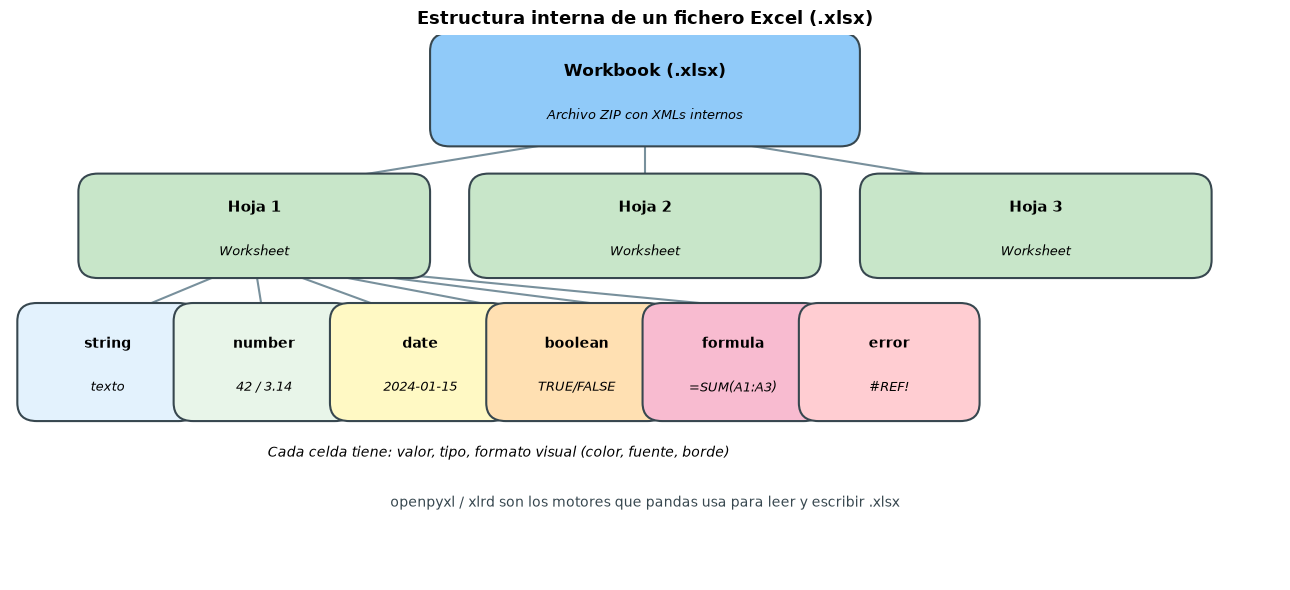

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis('off')

def box(ax, x, y, w, h, label, sub, clr, fs=11):
    p = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.2', lw=1.5,
                       edgecolor='#37474F', facecolor=clr, zorder=3)
    ax.add_patch(p)
    ax.text(x, y + (0.2 if sub else 0), label, ha='center', va='center',
            fontsize=fs, fontweight='bold', zorder=4)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=9, style='italic', zorder=4)

def edge(ax, x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], color='#78909C', lw=1.5, zorder=1)

# Workbook
box(ax, 6.5, 5.4, 4.0, 0.85, 'Workbook (.xlsx)', 'Archivo ZIP con XMLs internos', '#90CAF9', fs=12)

# Hojas
hojas = [(2.5, 3.9, 'Hoja 1'), (6.5, 3.9, 'Hoja 2'), (10.5, 3.9, 'Hoja 3')]
for x, y, lbl in hojas:
    box(ax, x, y, 3.2, 0.75, lbl, 'Worksheet', '#C8E6C9', fs=11)
    edge(ax, 6.5, 4.97, x, 4.27)

# Celdas
tipos = [
    (1.0, 2.4, 'string', 'texto', '#E3F2FD'),
    (2.6, 2.4, 'number', '42 / 3.14', '#E8F5E9'),
    (4.2, 2.4, 'date', '2024-01-15', '#FFF9C4'),
    (5.8, 2.4, 'boolean', 'TRUE/FALSE', '#FFE0B2'),
    (7.4, 2.4, 'formula', '=SUM(A1:A3)', '#F8BBD0'),
    (9.0, 2.4, 'error', '#REF!', '#FFCDD2'),
]
for x, y, lbl, sub, clr in tipos:
    box(ax, x, y, 1.45, 0.9, lbl, sub, clr, fs=10)
    edge(ax, 2.5, 3.52, x, 2.85)

ax.text(5.0, 1.4, 'Cada celda tiene: valor, tipo, formato visual (color, fuente, borde)',
        ha='center', va='center', fontsize=10, style='italic')
ax.text(6.5, 0.85, 'openpyxl / xlrd son los motores que pandas usa para leer y escribir .xlsx',
        ha='center', va='center', fontsize=10, color='#37474F')

plt.title('Estructura interna de un fichero Excel (.xlsx)', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()


## Tipos especiales en Excel

| Tipo | Comportamiento en Excel | Lectura con pandas |
|---|---|---|
| **Fecha** | Almacenado como número de días desde 1900 | `read_excel` convierte a `datetime64` |
| **Número** | `float` o `int` según formato de celda | Se lee como `float64` por defecto |
| **Fórmula** | Se evalúa en Excel; `.xlsx` guarda el resultado | pandas lee el **resultado** (no la fórmula) |
| **Celda combinada** | Una celda ocupa varias filas/columnas | Solo la primera celda tiene valor; el resto, `NaN` |
| **Hoja oculta** | Visible en el fichero aunque no en la UI | `pd.read_excel(f, sheet_name='Hoja_Oculta')` |

> **Precaución con fechas**: Excel tiene un error histórico (1900 no fue año bisiesto). En datasets muy antiguos puede haber un desplazamiento de un día.


## 2.7 Lectura de Excel con `read_excel`

```python
pd.read_excel(io, sheet_name=0, header=0, names=None,
              usecols=None, dtype=None, skiprows=None,
              nrows=None, na_values=None, engine='openpyxl')
```

| Parámetro | Descripcion | Ejemplo |
|---|---|---|
| `sheet_name` | Hoja a leer (nombre, índice o `None`=todas) | `sheet_name='Ventas'` |
| `header` | Fila con cabecera | `header=2` (tercera fila) |
| `usecols` | Columnas a leer (lista o rango Excel `'A:D'`) | `usecols='A,C:E'` |
| `skiprows` | Filas a saltar al inicio | `skiprows=3` |
| `nrows` | Número máximo de filas | `nrows=100` |
| `dtype` | Forzar tipos | `dtype={'precio': float}` |
| `engine` | Librería de lectura | `engine='openpyxl'` |

Cuando `sheet_name=None`, devuelve un **diccionario** `{nombre_hoja: DataFrame}`.


In [9]:
import pandas as pd
import openpyxl
import tempfile, os

tmpdir = tempfile.mkdtemp()
xlsx_path = f'{tmpdir}/ventas.xlsx'

# Crear Excel de ejemplo con dos hojas
wb = openpyxl.Workbook()
ws = wb.active
ws.title = 'Enero'
for row in [['ID','Producto','Cantidad','Precio','Fecha'],
             [1,'Laptop',2,999.99,'2024-01-15'],
             [2,'Raton',10,29.99,'2024-01-16'],
             [3,'Teclado',5,59.99,'2024-01-17']]:
    ws.append(row)
ws2 = wb.create_sheet('Febrero')
for row in [['ID','Producto','Cantidad','Precio','Fecha'],
             [4,'Monitor',1,349.99,'2024-02-01'],
             [5,'USB Hub',8,19.99,'2024-02-05']]:
    ws2.append(row)
wb.save(xlsx_path)
print(f'Excel creado: {os.path.basename(xlsx_path)} ({os.path.getsize(xlsx_path):,} bytes)\n')

# Leer hoja por defecto
df_enero = pd.read_excel(xlsx_path)
print('Hoja Enero (por defecto):')
print(df_enero)

# Leer hoja por nombre
df_feb = pd.read_excel(xlsx_path, sheet_name='Febrero')
print('\nHoja Febrero:')
print(df_feb)

# Leer todas las hojas
dfs = pd.read_excel(xlsx_path, sheet_name=None)
print(f'\nsheet_name=None -> {list(dfs.keys())}')
print(f'Total filas: {sum(len(d) for d in dfs.values())}')


Excel creado: ventas.xlsx (5,600 bytes)

Hoja Enero (por defecto):
   ID Producto  Cantidad  Precio       Fecha
0   1   Laptop         2  999.99  2024-01-15
1   2    Raton        10   29.99  2024-01-16
2   3  Teclado         5   59.99  2024-01-17

Hoja Febrero:
   ID Producto  Cantidad  Precio       Fecha
0   4  Monitor         1  349.99  2024-02-01
1   5  USB Hub         8   19.99  2024-02-05

sheet_name=None -> ['Enero', 'Febrero']
Total filas: 5


## 2.8 Escritura de Excel: `to_excel` y `ExcelWriter`

`to_excel` escribe un DataFrame en una hoja. `ExcelWriter` permite gestionar múltiples hojas y aplicar formato con `openpyxl`.

```python
# Una sola hoja
df.to_excel('salida.xlsx', index=False, sheet_name='Datos')

# Múltiples hojas con ExcelWriter
with pd.ExcelWriter('salida.xlsx', engine='openpyxl') as writer:
    df1.to_excel(writer, sheet_name='Hoja1', index=False)
    df2.to_excel(writer, sheet_name='Hoja2', index=False)
```

Parámetros de `to_excel`:
- `sheet_name` — nombre de la hoja destino
- `index` — incluir o no el índice de pandas
- `startrow` / `startcol` — posicion de inicio en la hoja
- `freeze_panes` — fijar filas/columnas al desplazarse: `freeze_panes=(1, 0)`
- `float_format` — formato de decimales


In [10]:
# Continua desde la celda anterior (xlsx_path debe existir)
import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment

df_prod = pd.DataFrame({
    'Producto': ['Laptop', 'Raton', 'Teclado', 'Monitor'],
    'Precio': [999.99, 29.99, 59.99, 349.99],
    'Stock': [15, 80, 45, 12],
})
df_clientes = pd.DataFrame({
    'Cliente': ['Ana Garcia', 'Luis Perez', 'Eva Lopez'],
    'Email': ['ana@mail.com', 'luis@mail.com', 'eva@mail.com'],
    'Total': [1029.98, 59.99, 379.98],
})

xlsx_out = xlsx_path.replace('ventas.xlsx', 'informe.xlsx')

with pd.ExcelWriter(xlsx_out, engine='openpyxl') as writer:
    df_prod.to_excel(writer, sheet_name='Productos', index=False, freeze_panes=(1, 0))
    df_clientes.to_excel(writer, sheet_name='Clientes', index=False, freeze_panes=(1, 0))

    # Formato basico con openpyxl: cabecera azul + negrita
    azul = PatternFill(start_color='1565C0', end_color='1565C0', fill_type='solid')
    for nombre_hoja in writer.sheets:
        ws = writer.sheets[nombre_hoja]
        for cell in ws[1]:
            cell.font = Font(bold=True, color='FFFFFF')
            cell.fill = azul
            cell.alignment = Alignment(horizontal='center')
        # Ajustar ancho de columnas
        for col in ws.columns:
            max_w = max(len(str(c.value or '')) for c in col)
            ws.column_dimensions[col[0].column_letter].width = max_w + 4

print(f'Excel con formato guardado en: {xlsx_out}')
# Verificar
for hoja, df in pd.read_excel(xlsx_out, sheet_name=None).items():
    print(f'\nHoja {hoja!r}: {len(df)} filas')
    print(df.to_string(index=False))


Excel con formato guardado en: C:\Users\aas19\AppData\Local\Temp\tmpfae1_vng/informe.xlsx

Hoja 'Productos': 4 filas
Producto  Precio  Stock
  Laptop  999.99     15
   Raton   29.99     80
 Teclado   59.99     45
 Monitor  349.99     12

Hoja 'Clientes': 3 filas
   Cliente         Email   Total
Ana Garcia  ana@mail.com 1029.98
Luis Perez luis@mail.com   59.99
 Eva Lopez  eva@mail.com  379.98


## 2.9 CSV vs Excel: cuándo usar cada uno

| Criterio | CSV | Excel (.xlsx) |
|---|---|---|
| Tamaño del fichero | Menor | Mayor (metadatos, XML interno) |
| Velocidad lectura | Más rápida | Más lenta |
| Múltiples hojas | No | Sí |
| Tipos preservados | No (todo texto) | Sí (fechas, números, booleanos) |
| Formato visual | No | Sí (colores, fuentes, anchos) |
| Interoperabilidad | Máxima | Alta (Excel, LibreOffice, pandas) |
| Apto para ML | Sí (con precaución) | No recomendado para datasets grandes |
| Procesamiento en streaming | Sí (línea a línea) | No |

**Usar CSV cuando**: intercambio de datos entre sistemas, datasets grandes, pipelines automatizados.

**Usar Excel cuando**: el destinatario es una persona, se necesitan múltiples hojas o formato visual, o el origen de los datos ya es un `.xlsx` empresarial.


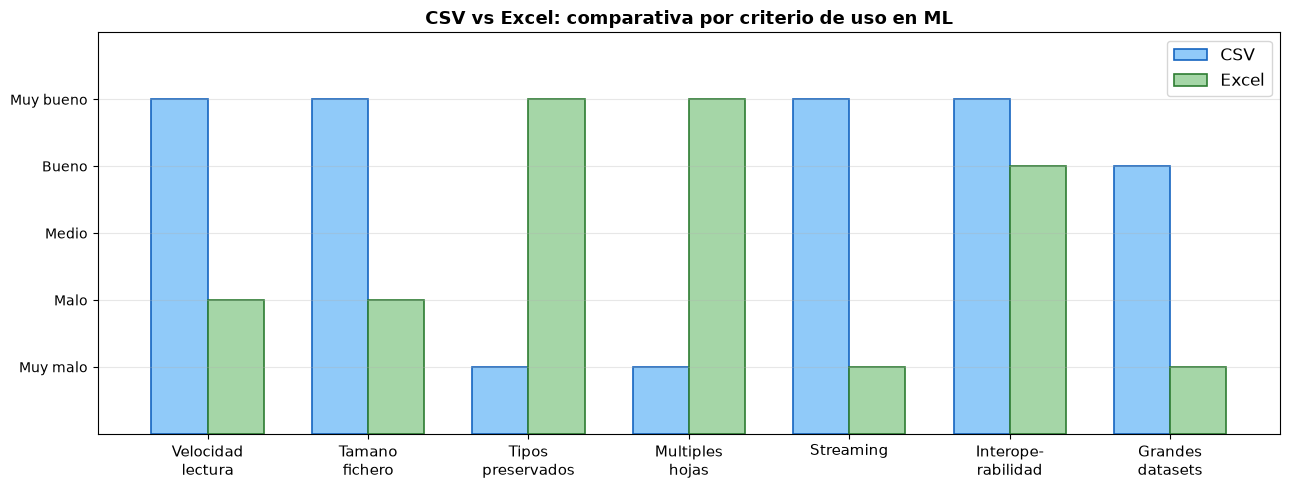

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

criterios = ['Velocidad\nlectura', 'Tamano\nfichero', 'Tipos\npreservados',
             'Multiples\nhojas', 'Streaming', 'Interope-\nrabilidad', 'Grandes\ndatasets']
csv_scores   = [5, 5, 1, 1, 5, 5, 4]
excel_scores = [2, 2, 5, 5, 1, 4, 1]

x = np.arange(len(criterios))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, csv_scores,   w, label='CSV',   color='#90CAF9', edgecolor='#1565C0', lw=1.2)
b2 = ax.bar(x + w/2, excel_scores, w, label='Excel', color='#A5D6A7', edgecolor='#2E7D32', lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels(criterios, fontsize=11)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['Muy malo', 'Malo', 'Medio', 'Bueno', 'Muy bueno'], fontsize=10)
ax.set_ylim(0, 6)
ax.legend(fontsize=12)
ax.set_title('CSV vs Excel: comparativa por criterio de uso en ML', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Resumen del bloque

**CSV:**
- Formato de texto plano con múltiples variantes (coma, punto y coma, tabulador, pipe).
- `pd.read_csv` ofrece parámetros clave: `sep`, `encoding`, `dtype`, `parse_dates`, `usecols`, `chunksize`.
- `to_csv` con `index=False` es la forma estándar de exportar DataFrames.
- Problemas habituales: tipos implícitos, codificaciones, nulos no estándar, campos multilínea.

**Excel:**
- Fichero ZIP con XML interno; permite múltiples hojas, tipos y formato visual.
- `pd.read_excel` con `sheet_name=None` carga todas las hojas como diccionario.
- `ExcelWriter` permite escribir múltiples hojas y aplicar formato básico con `openpyxl`.

**¿Cuál usar?** CSV para pipelines y grandes datasets; Excel cuando el destinatario es una persona.

---
*Siguiente bloque: formatos avanzados para ML — Parquet, HDF5 y Apache Arrow.*
